In [1]:
import matplotlib.dates as mdates
import datetime
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage
import DetectRadioburst_OSRA as drb


In [2]:
# Load data
fname = "/net/lyot/scratch3/vocks/OSRA/2003/CD_300/031027_300.roh"
dyspec, t_fits, f_fits = drb.read_osraf2(fname)

In [3]:
# Define time range
start_time = np.datetime64('2003-10-27T08:02:00.000')
end_time = np.datetime64('2003-10-27T08:12:00.000')
time_mask = (t_fits >= start_time) & (t_fits < end_time)

In [4]:
# Extract cutout data
t_fits_cutout = t_fits[time_mask]
dyspec_cutout = dyspec[time_mask, :]


In [5]:
# Preprocess data
data_fits_new, data_fits_new_smooth = drb.preproc2(dyspec_cutout, gauss_sigma=(5.5,0.0))


In [6]:
# Calculate vmin and vmax for colormap
data_safe_arr = data_fits_new_smooth.ravel()
data_safe = np.sort(data_safe_arr)[int(data_safe_arr.shape[0] * 0.02):int(data_safe_arr.shape[0] * 0.98)]
vmin = np.nanmean(data_safe) - 2 * np.nanstd(data_safe)
vmax = np.nanmean(data_safe) + 4 * np.nanstd(data_safe) + 0.5 * np.nanmax(data_safe)

In [7]:
# Normalize per frequency (optional)
tmp = np.nanmean(data_fits_new_smooth, axis=1)
sel = np.where(np.abs(tmp) < 1e-12)[0]
tmp[sel] = 1.0  # Avoid division by zero
new_array = data_fits_new_smooth / tmp[:, None] - 1  # Not used in plot

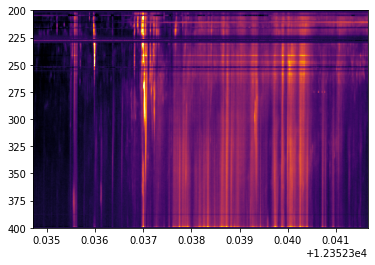

In [8]:
# Plot
fig = plt.figure(figsize=(6, 4))
ax = plt.gca()
im = ax.imshow(
    data_fits_new_smooth.T,
    aspect='auto',
    origin='lower',
    vmin=vmin,
    vmax=vmax,
    extent=drb.get_extent(t_fits_cutout, f_fits),
    cmap='inferno'
)

In [9]:
# Add colorbar
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Intensity (arbitrary units)')

In [10]:
plt.tight_layout()
plt.show()

<Figure size 432x288 with 0 Axes>

In [11]:
# binarization
bmap = drb.binarization(data_fits_new_smooth,N_order=8,peak_r=0.9993)

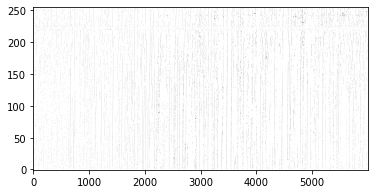

In [12]:
fig,ax = plt.subplots(1,1,figsize=[6,3])
ax.imshow(1-bmap.T,aspect='auto', origin='lower',cmap='gray')

In [13]:
f_100 = data_fits_new_smooth[:,100]

print (f_100)

print(f_100.shape)

[-0.04273172 -0.04332308 -0.04395141 ... -0.00319097 -0.00314541
 -0.00313128]
(6000,)


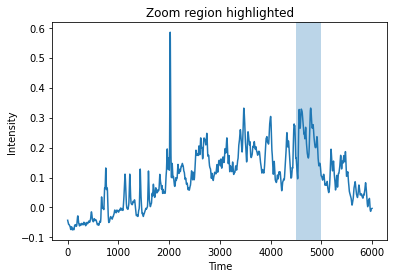

In [14]:
plt.figure()
plt.plot(f_100)
plt.axvspan(4500, 5000, alpha=0.3)
plt.xlabel("Time")
plt.ylabel("Intensity")
plt.title("Zoom region highlighted")
plt.show()

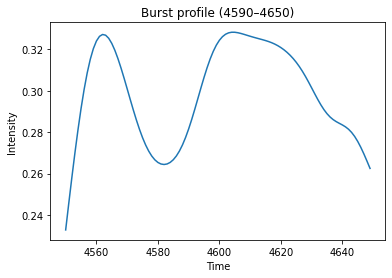

In [15]:
t_start = 4550
t_end = 4650

f_zoom = f_100[t_start:t_end]

plt.figure()
plt.plot(range(t_start, t_end), f_zoom)
plt.xlabel("Time")
plt.ylabel("Intensity")
plt.title("Burst profile (4590–4650)")
plt.show()

Text(0.5, 1.0, 'overplot binary map to spectrum')

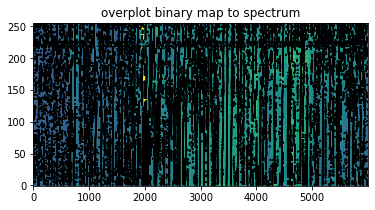

In [16]:
fig = plt.figure(figsize=[6,3])
plt.imshow(data_fits_new_smooth.T,aspect='auto',origin='lower',vmax=vmax,vmin=vmin/2-vmax/2)
plt.contour(bmap.T,[0,0.5,1],colors='k')
plt.title("overplot binary map to spectrum")

In [17]:
# detect verticle features
lines = drb.hough_detect(
    bmap,                        # binary_map
    dyspec,                       # dyspec (raw spectrogram)
    threshold=30,                # minimum votes for line detection
    line_gap=10,                 # max gap between line segments
    line_length=50,             # minimum line length in pixels
    theta=np.linspace(          # range of angles to search
        np.pi/2 - np.pi/4,  # start angle: 45° (π/4 = 45°)ie (180/2) -(180/4)
        np.pi/2 - 0.5/180*np.pi,  # end angle: ~89.5° (just below vertical)
        500 )  )                # number of angles to try
  

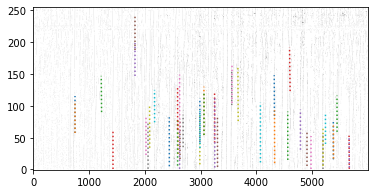

In [18]:
fig,ax = plt.subplots(1,1,figsize=[6,3])
lines = sorted(lines, key=lambda i: i[0][1])
ax.imshow(1-bmap.T,aspect='auto',origin='lower',cmap='gray')
for line in lines:
    p0,p1= line
    ax.plot( (p0[1], p1[1]),(p0[0], p1[0]),':')

In [19]:
# Group lines
line_sets = drb.line_grouping(lines)
# group the detected lines into group in regard of events

(4500.0, 5000.0)

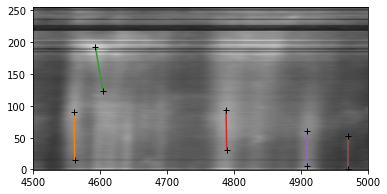

In [20]:
# Plot grouped lines
fig,ax = plt.subplots(1,1,figsize=[6,3])
ax.imshow(data_fits_new_smooth.T,aspect='auto',origin='lower',vmax=vmax,vmin=vmin,cmap='gray')

for idx,lines in enumerate(line_sets):
    for line in lines:
        p0,p1= line
        ax.plot( (p0[1], p1[1]),(p0[0], p1[0]),color='C'+str(idx+1))
        ax.plot( (p0[1], p1[1]),(p0[0], p1[0]),'k+',zorder=10)
ax.set_xlim((4500,5000))
#ax.set_ylim((bmap.shape[0], 0))

In [21]:
len(line_sets)

30

In [ ]:
from type3detectosra import Radiotools as rt

# Example: velocity estimate (kept as comment, reformatted)
# v_est = (rt.freq_to_R(20e6) - rt.freq_to_R(80e6)) / rt.C_RS

# --- Extract burst information ---
results = drb.get_info_from_linegroupt_fits_cutout(
    line_sets,
    t_fits_cutout,
    f_fits
)

(
    v_beam,
    f_range_burst,
    t_range_burst,
    model_curve_set,
    t_set_arr_set,
    f_set_arr_set,
    t_model_arr,
    f_model_arr
) = results

# --- Plotting ---
has_data = (
    t_set_arr_set is not None and
    f_set_arr_set is not None and
    len(t_set_arr_set) > 0 and
    len(f_set_arr_set) > 0
)

if has_data:
    plt.plot(t_set_arr_set[0], f_set_arr_set[0], marker='x', linestyle='None')
else:
    print("No data to plot.")

NameError: name 'model_curve_set' is not defined

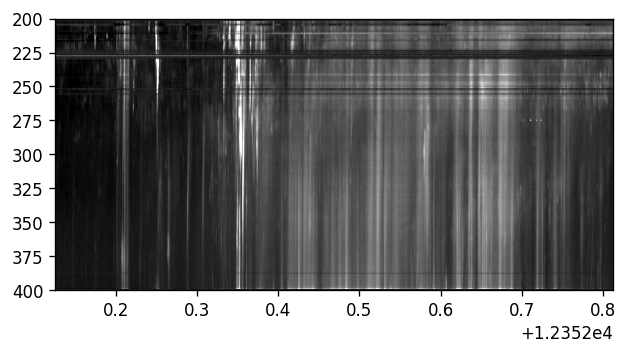

In [22]:
fig,ax = plt.subplots(1,1,figsize=[6,3],dpi=120)
lines = sorted(lines, key=lambda i: i[0][1])
ax.imshow(data_fits_new.T,aspect='auto',origin='lower', vmax=vmax,vmin=vmin,cmap='gray',
                   extent=drb.get_extent(t_fits, f_fits))
for idx,model in enumerate(model_curve_set):
    if (v_beam[idx] > 0) and (v_beam[idx] < 0.9):
        plt.plot(model[0],model[1],ls='--')
        plt.plot(t_range_burst[idx],f_range_burst[idx],'k+')
    


ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Frequency (MHz)')
ax.set_title("Lines of detected burst CD_300/031027_300 OSRA" )


#ax.set_xlim([t_fits[200],t_fits[400]])
#plt.ylim([10,88])